In [1]:
# === Standard Library ===
import os
import gc
import datetime
import warnings
from collections import Counter

# === Data & Math ===
import numpy as np
import pandas as pd
import torch

# === Hugging Face & Transformers ===
import transformers
from huggingface_hub import snapshot_download
from datasets import load_from_disk, Dataset

# === Geneformer ===
from geneformer import EmbExtractor, Classifier
import pickle

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# ==============================
# Environment setup
# ==============================
import os
import sys
import torch
import gc
import warnings 

env_path = "/home/btanasa/miniconda3/envs/torch-cu"
os.environ["CONDA_PREFIX"] = env_path
os.environ["CONDA_DEFAULT_ENV"] = "torch-cu"
os.environ["RETICULATE_PYTHON"] = f"{env_path}/bin/python"
print("✅ Environment set to torch-cu")
print("Python executable:", sys.executable)


print("✅ Environment set to torch_cu")
print("Python executable:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))

# Verify the setup
try:
    import torch
    print("✅ PyTorch available:", torch.__version__)
    print("✅ CUDA available:", torch.cuda.is_available())
except ImportError as e:
    print("❌ PyTorch import failed:", e)

try:
    from geneformer import TranscriptomeTokenizer
    print("✅ Geneformer available")
except ImportError as e:
    print("❌ Geneformer import failed:", e)

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")

print("✅ Environment variable set!")
print(f"PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("✅ Environment variable set!")
print(f"PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF')}")


✅ Environment set to torch-cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
✅ Environment set to torch_cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
CONDA_PREFIX: /home/btanasa/miniconda3/envs/torch-cu
CONDA_DEFAULT_ENV: torch-cu
✅ PyTorch available: 2.5.1
✅ CUDA available: True
✅ Geneformer available
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
CUDA memory after empty_cache: 0.00 GB
✅ Environment variable set!
PYTORCH_CUDA_ALLOC_CONF: None
✅ Environment variable set!
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [3]:
# the model was saved in the location :
# /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/

# model_version1="V1"
model_version2="V2"

token_dictionary_file = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl"  # or your V1 or V2 token dict
token_dict_path = token_dictionary_file

with open(token_dictionary_file, "rb") as f:
    token_dict = pickle.load(f)

print(type(token_dict))
print(len(token_dict))

# Show first 20 entries
for i, (gene, token_id) in enumerate(token_dict.items()):
    print(f"{gene} → {token_id}")
    if i >= 6:
        break

# Convert to DataFrame
token_df = pd.DataFrame(list(token_dict.items()), columns=["Ensembl_ID", "Token_ID"])
print(token_df)


<class 'dict'>
20275
<pad> → 0
<mask> → 1
<cls> → 2
<eos> → 3
ENSG00000000003 → 4
ENSG00000000005 → 5
ENSG00000000419 → 6
            Ensembl_ID  Token_ID
0                <pad>         0
1               <mask>         1
2                <cls>         2
3                <eos>         3
4      ENSG00000000003         4
...                ...       ...
20270  ENSG00000292379     20270
20271  ENSG00000292438     20271
20272  ENSG00000293543     20272
20273  ENSG00000293552     20273
20274  ENSG00000293553     20274

[20275 rows x 2 columns]


In [4]:
# =============================================================================
# FOLDERS and INFORMATION
# =============================================================================

model_directory = "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/"      # pretrained or fine-tuned model folder
input_data_file = "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset"

# Verify the paths

if os.path.exists(token_dictionary_file):
    print(f"✅ File exists: {token_dictionary_file}")
else:
    print(f"❌ File does NOT exist: {token_dictionary_file}")

if os.path.exists(model_directory):
    print(f"✅ File exists: {model_directory}")
else:
    print(f"❌ File does NOT exist: {model_directory}")

if os.path.exists(input_data_file):
    print(f"✅ File exists: {input_data_file}")
else:
    print(f"❌ File does NOT exist: {input_data_file}")

# Load the dataset
print(f"\n�� Loading dataset...")
try:
    dataset = load_from_disk(input_data_file)
    print(f"✅ Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset

�� Loading dataset...
✅ Dataset loaded successfully!


In [5]:
# =============================================================================
# BASIC INFORMATION
# =============================================================================

print(f"\n📊 BASIC DATASET INFORMATION:")
print(f"   Total cells: {len(dataset):,}")
print(f"   Dataset type: {type(dataset)}")
print(f"   Number of columns: {len(dataset.column_names)}")

print(f"\n📋 METADATA :")
print(f"   Available metadata : {dataset.column_names}")

print(f"\n�� FEATURE SCHEMA:")
for col_name in dataset.column_names:
    col_type = dataset.features[col_name]
    print(f"   {col_name}: {col_type}")


# Check number of rows and columns
print(dataset.num_rows)
print(dataset.column_names)

# View a sample row
# print(dataset[0])
# print(dataset[1])
# print(dataset[2])

# Data composition :

import pandas as pd

# Convert to DataFrame (if small enough)
df = dataset.to_pandas()

# Unique medical conditions
print("🧍 Unique medical conditions:", df['condition'].nunique())
print(df['condition'].value_counts(), end="\n\n")

# Unique cell types
print("🔬 Unique cell types:", df['class'].nunique())
print(df['class'].value_counts(), end="\n\n")

# Broad cell types
print("🩺 Broad classes of cell populations:", df['broad_class'].nunique())
print(df['broad_class'].value_counts(), end="\n\n")


📊 BASIC DATASET INFORMATION:
   Total cells: 2,000
   Dataset type: <class 'datasets.arrow_dataset.Dataset'>
   Number of columns: 8

📋 METADATA :
   Available metadata : ['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length', 'why']

�� FEATURE SCHEMA:
   input_ids: List(Value('int32'))
   obs_names: Value('string')
   leiden: Value('string')
   class: Value('string')
   condition: Value('string')
   broad_class: Value('string')
   length: Value('int64')
   why: Value('string')
2000
['input_ids', 'obs_names', 'leiden', 'class', 'condition', 'broad_class', 'length', 'why']
🧍 Unique medical conditions: 3
condition
5d_HIE     1170
non-HIE     475
2mo_HIE     355
Name: count, dtype: int64

🔬 Unique cell types: 8
class
Astroglia                615
Imm-MGE                  272
Inh-Injured              241
Medium-Spiny-Neuron_?    207
activated-NSCs           178
Imm-CGE                  165
Myelinating-Olig         164
OPC                      158
Name: count, d

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG = {

    # Dataset paths
    "input_data_file": "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset",

    # Model paths
    "model_path": "/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/",
    "token_dictionary_file": "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl",

    "target_size": 10000,  # Set to None to use full dataset
    "random_state": 73,

    # Model configuration
    "model_version": "V2",
    "freeze_layers": 2,
    "forward_batch_size": 200,
    "nproc": 10, #

    # Output
    "output_prefix": "hypoxia_2000cells_ISP"
}

In [7]:
# =============================================================================
# SETUP AND VERIFICATION
# =============================================================================

print("🚀 Starting Hypoxia Geneformer ISP Pipeline")
print("=" * 60)

# Create timestamped output directory
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
datestamp_min = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}"

output_dir = f"/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/{datestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"📁 Output directory: {output_dir}")
print(f"📅 Timestamp: {datestamp}")

# Verify all required files exist
print(f"\n🔍 Verifying files...")
required_files = [
    ("Input dataset", CONFIG["input_data_file"]),
    ("Model directory", CONFIG["model_path"]),
    ("Token dictionary", CONFIG["token_dictionary_file"])
]

for name, path in required_files:
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path}")
        print(f"   File not found - please check the path")
        # exit()

🚀 Starting Hypoxia Geneformer ISP Pipeline
📁 Output directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910
📅 Timestamp: 250829130910

🔍 Verifying files...
✅ Input dataset: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset
✅ Model directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_out/250821141257/250821_geneformer_cellClassifier_hypoxia_condition_classifier_optimized/ksplit1/checkpoint-1400/
✅ Token dictionary: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl


In [8]:
# === condition ===
# Unique (3): ['2mo_HIE', '5d_HIE', 'non-HIE']

# Counts: condition
# 5d_HIE     60633
# non-HIE    25118
# 2mo_HIE    18687

print(output_dir)

# 🔬 Unique cell types: 8
# class
# Astroglia                615
# Imm-MGE                  272
# Inh-Injured              241
# Medium-Spiny-Neuron_?    207
# activated-NSCs           178
# Imm-CGE                  165
# Myelinating-Olig         164
# OPC                      158

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910


In [9]:
# extract embedding in CLS model

In [10]:
import time

try:
    from geneformer import EmbExtractor

    # Define perturbation parameters
    cell_states_to_model = {
        "state_key": "condition",
        "start_state": "5d_HIE",
        "goal_state": "non-HIE",
        "alt_states": ["2mo_HIE"]
    }

    # Use all disease states (no filtering)
    
    # filter_data_dict = None
    filter_data_dict = {"class":["activated-NSCs"]}
    # filter_data_dict={"class":["Astroglia","Imm-MGE","Imm-CGE"]} 

    print(f"Perturbation goal: 5d_HIE → non-HIE (with 2mo_HIE as alternative)")
    print(f"Cell states: {cell_states_to_model}")
 
    # Setup embedding extractor
    print(f"🔧 Initializing embedding extractor...")
    embex = EmbExtractor(
        model_type = "CellClassifier", 
        num_classes = 3,
        filter_data = filter_data_dict,
        max_ncells = 1000,  # maximum number of cells to use 
        emb_layer = 0,
        summary_stat = "exact_mean",
        forward_batch_size = 16, # 256 in the tutorial
        model_version = "V2",
        nproc = 20, # 1
        emb_mode = "cls"             # <-- ADD for V2
        # cell_emb_style="mean_pool" # <-- REMOVE in CLS mode
    )

     # Get state embeddings with timing
    print(f"📊 Extracting state embeddings...")
    start_time = time.time()
    
    # Get state embeddings
    print(f"📊 Extracting state embeddings...")
    state_embs_dict = embex.get_state_embs(
        cell_states_to_model,
        CONFIG["model_path"],
        CONFIG["input_data_file"],
        output_dir,
        CONFIG["output_prefix"]
    )
    print(f"✅ State embeddings extracted")

    end_time = time.time()
    execution_time = end_time - start_time
    
    print(f"✅ State embeddings extracted")
    print(f"⏱️ Execution time: {execution_time:.2f} seconds ({execution_time/60:.2f} minutes)")

except Exception as e:
    print(f"❌ State embedding extraction failed: {e}")
    print(f"   Cannot proceed without state embeddings")
    import traceback
    traceback.print_exc()
    # exit()

import pickle
import numpy as np

# Reconstruct the pickle filename
pkl_file = os.path.join(output_dir, f"{CONFIG['output_prefix']}.pkl")

print(f"📁 Output directory: {output_dir}")
print(f"🏷️ Output prefix: {CONFIG['output_prefix']}")
print(f"📄 Reconstructed pickle file: {pkl_file}")

# Check if the file exists
if os.path.exists(pkl_file):
    print(f"✅ File exists: {pkl_file}")
else:
    print(f"❌ File does NOT exist: {pkl_file}")


# Load the file
with open(pkl_file, 'rb') as f:
    data = pickle.load(f)

# Show what's inside
print("Keys:", list(data.keys()))
print("Number of states:", len(data))

# Show details for each state
for state, emb in data.items():
    print(f"\n{state}:")
    print(f"  Type: {type(emb)}")
    
    # Convert to numpy if it's a tensor
    if hasattr(emb, 'detach'):
        emb_array = emb.detach().cpu().numpy()
    else:
        emb_array = np.array(emb)
    
    print(f"  Shape: {emb_array.shape}")
    print(f"  First 5 values: {emb_array.flatten()[:10]}")

# Show size of each vector
for state, emb in data.items():
    print(f"{state}: {emb.shape}")

# So when you see:
emb_array.flatten()[:5]


Perturbation goal: 5d_HIE → non-HIE (with 2mo_HIE as alternative)
Cell states: {'state_key': 'condition', 'start_state': '5d_HIE', 'goal_state': 'non-HIE', 'alt_states': ['2mo_HIE']}
🔧 Initializing embedding extractor...
📊 Extracting state embeddings...
📊 Extracting state embeddings...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

✅ State embeddings extracted
✅ State embeddings extracted
⏱️ Execution time: 20.05 seconds (0.33 minutes)
📁 Output directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910
🏷️ Output prefix: hypoxia_2000cells_ISP
📄 Reconstructed pickle file: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910/hypoxia_2000cells_ISP.pkl
✅ File exists: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910/hypoxia_2000cells_ISP.pkl
Keys: ['5d_HIE', 'non-HIE', '2mo_HIE']
Number of states: 3

5d_HIE:
  Type: <class 'torch.Tensor'>
  Shape: (768,)
  First 5 values: [ 1.3126678   0.11623995  0.02552821  0.25740132 -1.7971445  -0.3860813
 -0.30947897 -1.959606   -0.20772016  1.0882146 ]

non-HIE:
  Type: <class 'torch.Tensor'>
  Shape: (768,)
  First 5 values: [-0.55

array([-0.482322 ,  0.8576674, -0.7484102, -0.0893751,  1.9111013],
      dtype=float32)

In [11]:
print(output_dir)
print(CONFIG["output_prefix"])
print(CONFIG["input_data_file"])

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910
hypoxia_2000cells_ISP
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.dataset


In [12]:
# ===============================
# Extract per-cell CLS embeddings + visualize 
# ===============================
import os, time, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---- Prefixes: keep original, add a separate one for cells
state_prefix = CONFIG["output_prefix"]
cell_prefix  = f"{state_prefix}_cells"
CONFIG["cell_output_prefix"] = cell_prefix
print("🔖 State prefix:", state_prefix)
print("🔖 Cell  prefix:", cell_prefix)

# ---- Create a dedicated output_dir for cell embeddings ----
output_dir_cells = Path(output_dir) / "cell_embeddings"
output_dir_cells.mkdir(parents=True, exist_ok=True)

# ---- States and optional filtering
cell_states_to_model = {
    "state_key": "condition",
    "start_state": "5d_HIE",
    "goal_state": "non-HIE",
    "alt_states": ["2mo_HIE"],
}
filter_data_dict = {"class": ["activated-NSCs"]}  # or None
print(f"🎯 States: {cell_states_to_model}")
print(f"🔎 Filter: {filter_data_dict}")

# ---- EmbExtractor (CLS mode for V2)
from geneformer import EmbExtractor
safe_nproc = min(32, (os.cpu_count() or 8))
embex_cell = EmbExtractor(
    model_type="CellClassifier",
    num_classes=3,
    filter_data=filter_data_dict,
    max_ncells = 1000,           # adjust for speed/coverage
    emb_layer = 0,
    # summary_stat="exact_mean", # harmless here
    forward_batch_size= 12,    # bump if plenty of VRAM
    model_version="V2",
    nproc = 30 ,
    emb_mode="cell",
)


# Get cell embeddings with timing
print(f"📊 Extracting cell embeddings...")
start_time = time.time()
    
# Get state embeddings
print(f"📊 Extracting cell embeddings...")
state_embs_dict = embex_cell.extract_embs(
        CONFIG["model_path"],
        CONFIG["input_data_file"],
        output_dir_cells ,
        cell_prefix
    )

print(f"✅ Cell embeddings extracted")

end_time = time.time()
execution_time = end_time - start_time
    
print(f"✅ Cell embeddings extracted")
print(f"⏱️ Execution time: {execution_time:.2f} seconds ({execution_time/60:.2f} minutes)")

print(output_dir_cells)

🔖 State prefix: hypoxia_2000cells_ISP
🔖 Cell  prefix: hypoxia_2000cells_ISP_cells
🎯 States: {'state_key': 'condition', 'start_state': '5d_HIE', 'goal_state': 'non-HIE', 'alt_states': ['2mo_HIE']}
🔎 Filter: {'class': ['activated-NSCs']}
📊 Extracting cell embeddings...
📊 Extracting cell embeddings...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


  0%|          | 0/15 [00:00<?, ?it/s]

✅ Cell embeddings extracted
✅ Cell embeddings extracted
⏱️ Execution time: 14.90 seconds (0.25 minutes)
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250829130910/cell_embeddings


In [ ]:
# there are 178 cells "activated-NPC"
# in the output file: wc -l hypoxia_2000cells_ISP_cells.csv 
# 179 hypoxia_2000cells_ISP_cells.csv

# 1. The 0,1,2,..,767 part
# Those are the column names for the embedding dimensions.
# Each embedding vector has length = hidden size of your Geneformer model.
# For Geneformer V2, te hidden size is 768 → so the CSV has 768 columns labeled 0 through 767.
# Each column corresponds to one coordinate of the CLS embedding in that latent space.

# 2. The rows of numbers like -0.2571213, -0.40348822, ...
# Those are the actual values of the embedding for one cell.
# Each row = one cell.
# Each entry in that row = the embedding value at that dimension.

# So for example:
#    cell_1 → [ -0.257, -0.403, 1.280, -0.345, ...,  -1.961 ]
#    cell_2 → [  0.123,  0.542, -0.983,  0.661, ...,   0.248 ]
#    ...

# 3. What’s missing?
# Usually you also want a label column (state) so you know which condition each cell belongs to. In the earlier code I gave you, 
# we appended df["state"] = labels so the CSV has both the embeddings and a state column at the end.

# https://geneformer.readthedocs.io/en/latest/geneformer.emb_extractor.html
 # labels_to_plotNone, list

In [ ]:
# trying to extract gene embeddings

In [16]:
# ===============================
# Extract per-cell CLS embeddings + visualize (no helper function)
# ===============================
import os, time, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---- Prefixes: keep original, add a separate one for cells
state_prefix = CONFIG["output_prefix"]
gene_prefix  = f"{state_prefix}_genes"
CONFIG["cell_output_prefix"] = gene_prefix
print("🔖 State prefix:", state_prefix)
print("🔖 Gene  prefix:", gene_prefix)

# ---- Create a dedicated output_dir for cell embeddings ----
output_dir_genes = Path(output_dir) / "gene_embeddings"
output_dir_genes.mkdir(parents=True, exist_ok=True)

# ---- States and optional filtering
cell_states_to_model = {
    "state_key": "condition",
    "start_state": "5d_HIE",
    "goal_state": "non-HIE",
    "alt_states": ["2mo_HIE"],
}
filter_data_dict = {"class": ["activated-NSCs"]}  # or None
print(f"🎯 States: {cell_states_to_model}")
print(f"🔎 Filter: {filter_data_dict}")

# ---- EmbExtractor (CLS mode for V2)
from geneformer import EmbExtractor
safe_nproc = min(32, (os.cpu_count() or 8))
embex_gene = EmbExtractor(
    model_type="CellClassifier",
    num_classes=3,
    filter_data=filter_data_dict,
    max_ncells = 1000,           # adjust for speed/coverage
    emb_layer = 0,
    # summary_stat="exact_mean", # harmless here
    forward_batch_size= 12,    # bump if plenty of VRAM
    model_version="V2",
    nproc = 30 ,
    emb_mode="gene",
)


# Get cell embeddings with timing
print(f"📊 Extracting gene embeddings...")
start_time = time.time()
    
# Get state embeddings
print(f"📊 Extracting gene embeddings...")
state_embs_dict = embex_gene.extract_embs(
        CONFIG["model_path"],
        CONFIG["input_data_file"],
        output_dir_genes ,
        gene_prefix
    )

print(f"✅ State embeddings extracted")

end_time = time.time()
execution_time = end_time - start_time
    
print(f"✅ Gene embeddings extracted")
print(f"⏱️ Execution time: {execution_time:.2f} seconds ({execution_time/60:.2f} minutes)")

print(output_dir_genes)

🔖 State prefix: hypoxia_2000cells_ISP
🔖 Gene  prefix: hypoxia_2000cells_ISP_genes
🎯 States: {'state_key': 'condition', 'start_state': '5d_HIE', 'goal_state': 'non-HIE', 'alt_states': ['2mo_HIE']}
🔎 Filter: {'class': ['activated-NSCs']}
📊 Extracting gene embeddings...
📊 Extracting gene embeddings...


  0%|          | 0/15 [00:00<?, ?it/s]

✅ State embeddings extracted
✅ Gene embeddings extracted
⏱️ Execution time: 17.71 seconds (0.30 minutes)
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250828123842/gene_embeddings


In [ ]:
# visualization to follow !

In [12]:
# What your output shows
# Output directory: /mnt/.../hypoxia_2000cells_OPC_ISP.pkl → this pickle holds one embedding per state.
# Keys: ['5d_HIE', 'non-HIE', '2mo_HIE'] → these are your cell-state groups (start, goal, alt).
# Values: each is a torch.Tensor of shape (768,).

# This tells us:
# The model version you’re using (V2, 104M params) has a hidden size of 768.
# Each state is represented by a single 768-dimensional vector = the CLS embedding averaged over all cells of that state.
# 5d_HIE → [768-dim vector]
# non-HIE → [768-dim vector]
# 2mo_HIE → [768-dim vector]

#    🔹 How to interpret these embeddings
# Each 768-d vector is a compressed representation of the transcriptome state of that condition, as “understood” by Geneformer.
# Cosine similarity or Euclidean distance between them measures transcriptomic similarity/dissimilarity between states.
# Example: cos(5d_HIE, non-HIE) tells you how close the early hypoxia state is to normal cells.
# When you run ISP (in silico perturbation), new CLS embeddings are generated for perturbed cells, 
# and their shifts relative to these state vectors (esp. toward/away from goal_state) are the basis of goal-state-shift statistics.

# Contrast with "cell" mode
# emb_mode="cls" → one embedding per cell (or aggregated per state), capturing global cell-level context.
# emb_mode="cell" → averages over all token embeddings of the cell, so it’s more like a bag-of-genes representation.

# In practice:

#" cls" is better for tasks like classification and ISP goal-shift.
# "cell" can be more interpretable when you want token-level resolution.


In [20]:
print("The analysis on the state embeddings:")

# to print the state embeddings, from the pickle file :

The analysis on the state embeddings:


📄 State-embeddings pickle: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250828123842/hypoxia_2000cells_ISP.pkl
✅ Loaded 3 states; embedding dim = 768
  • 5d_HIE: shape=(768,), first5=[ 1.313  0.116  0.026  0.257 -1.797]
  • non-HIE: shape=(768,), first5=[-0.559  0.021  1.239 -0.444 -0.051]
  • 2mo_HIE: shape=(768,), first5=[-0.482  0.858 -0.748 -0.089  1.911]
📈 PCA explained variance ratio (PC1, PC2): [0.535099983215332, 0.4648999869823456]


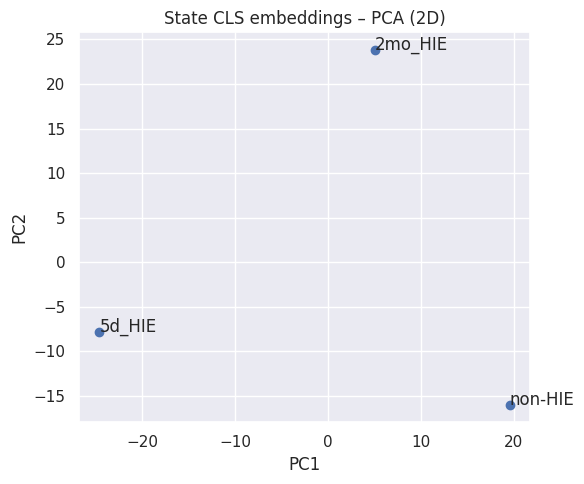

🖼️ Saved PCA plot → /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250828123842/embedding_plots/hypoxia_2000cells_ISP_state_cls_pca.png
💾 Saved per-state vectors → /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250828123842/embedding_plots/hypoxia_2000cells_ISP_state_cls_vectors.csv


In [21]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA

# --- locate the pickle saved by EmbExtractor.get_state_embs ---
pkl_path = os.path.join(output_dir, f"{CONFIG['output_prefix']}.pkl")
print("📄 State-embeddings pickle:", pkl_path)
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f"Not found: {pkl_path}")

# --- load dict: {state_name: 1D vector (768,)} ---
with open(pkl_path, "rb") as f:
    state_embs = pickle.load(f)

state_names = list(state_embs.keys())
X = np.stack([
    (v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v)).reshape(-1)
    for v in state_embs.values()
])  # shape: [n_states, D]

print(f"✅ Loaded {len(state_names)} states; embedding dim = {X.shape[1]}")
for s, v in zip(state_names, X):
    print(f"  • {s}: shape={v.shape}, first5={np.round(v[:5], 3)}")

# --- PCA to 2D ---
pca = PCA(n_components=2, random_state=0)
Y = pca.fit_transform(X)  # [n_states, 2]
expl_var = pca.explained_variance_ratio_
print("📈 PCA explained variance ratio (PC1, PC2):",
      np.round(expl_var[:2], 4).tolist())

# --- plotting (one point per state) ---
plot_dir = Path(output_dir) / "embedding_plots"
plot_dir.mkdir(parents=True, exist_ok=True)
png_path = plot_dir / f"{CONFIG['output_prefix']}_state_cls_pca.png"

plt.figure(figsize=(6, 5))
plt.scatter(Y[:, 0], Y[:, 1])
for i, name in enumerate(state_names):
    plt.text(Y[i, 0], Y[i, 1], name)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("State CLS embeddings – PCA (2D)")
plt.tight_layout()
plt.savefig(png_path, dpi=200)
plt.show()
plt.close()
print("🖼️ Saved PCA plot →", png_path)

# --- (optional) save the numeric table for reference ---
out_csv = plot_dir / f"{CONFIG['output_prefix']}_state_cls_vectors.csv"
pd.DataFrame(X, index=state_names).to_csv(out_csv, header=False)
print("💾 Saved per-state vectors →", out_csv)


In [23]:
# create the output folders

# Output folders
isp_output_dir = os.path.join(output_dir, "isp")
isp_stats_dir  = os.path.join(output_dir, "isp_stats")
os.makedirs(isp_output_dir, exist_ok=True)
os.makedirs(isp_stats_dir, exist_ok=True)

In [ ]:
print(isp_output_dir)
print(isp_stats_dir)

In [15]:
# === Geneformer ===
from geneformer import EmbExtractor, Classifier, InSilicoPerturber, InSilicoPerturberStats
import pickle

In [16]:
print(output_dir)
print(isp_output_dir)
print(isp_stats_dir)

/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827103252
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827103252/isp
/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_5_full_h5ad_aug20_subsample2000cells_dataset_oldlabel.isp/250827103252/isp_stats


In [ ]:
genes_to_perturb = "all"

import time

# Time the ISP initialization
print("�� Initializing InSilicoPerturber...")
init_start = time.time()

isp = InSilicoPerturber(
    perturb_type = "delete",
    perturb_rank_shift = None,
    genes_to_perturb = genes_to_perturb,
    # genes_to_perturb = "all",
    combos = 0,
    anchor_gene = None,
    model_type = "CellClassifier",
    num_classes = 3,
    emb_mode = "cls",                     # ✅ Use CLS embedding for V2
    # emb_mode = "cell",                    # SET TO "CELL" FOR V1 MODEL. FOR V2, SHOULD BE "CLS" (current default).
    # emb_mode = "cls_and_gene",
    filter_data = filter_data_dict,
    cell_states_to_model = cell_states_to_model,
    state_embs_dict = state_embs_dict,
    max_ncells = 1200,
    emb_layer = 0,
    forward_batch_size = 32,
    model_version = "V2",                 # ✅ Matches CLS usage
    nproc = 130
)

# --- avoid the Column * int bug by skipping the special-token code path ---
if hasattr(isp, "special_token"):
    isp.special_token = False

# Time the perturbation execution
print("🧬 Running ISP perturbation...")
perturb_start = time.time()

isp.perturb_data(
    CONFIG["model_path"],
    CONFIG["input_data_file"],
    isp_output_dir,
    f"{CONFIG['output_prefix']}_tf"
)

perturb_time = time.time() - perturb_start
total_time = time.time() - init_start

print(f"✅ ISP outputs -> {isp_output_dir}")
print(f"⏱️ Perturbation execution time: {perturb_time:.2f} seconds ({perturb_time/60:.2f} minutes)")
print(f"⏱️ Total time (init + execution): {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

# Goal-state-shift statistics (Chronic → Normoxia, Acute as alt)
print("�� Initializing InSilicoPerturberStats...")
stats_init_start = time.time()

ispstats = InSilicoPerturberStats(
    mode="goal_state_shift",
    genes_perturbed = genes_to_perturb,
    combos = 0,
    anchor_gene = None,
    cell_states_to_model = cell_states_to_model,
    model_version = "V2",
    token_dictionary_file = token_dictionary_file
)

stats_init_time = time.time() - stats_init_start
total_time_with_stats = time.time() - init_start

print(f"✅ InSilicoPerturberStats initialized in {stats_init_time:.2f} seconds")
print(f"⏱️ Total time (init + execution + stats_init): {total_time_with_stats:.2f} seconds ({total_time_with_stats/60:.2f} minutes)")

# Time the statistics computation
print("📈 Computing statistics...")
stats_comp_start = time.time()

ispstats.get_stats(
    isp_output_dir,
    None,
    isp_stats_dir,
    f"{CONFIG['output_prefix']}_genes"
)

stats_comp_time = time.time() - stats_comp_start

print(f"✅ Statistics computed -> {isp_stats_dir}")
print(f"⏱️ Statistics computation time: {stats_comp_time:.2f} seconds ({stats_comp_time/60:.2f} minutes)")

�� Initializing InSilicoPerturber...
🧬 Running ISP perturbation...


  0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# After ISP execution, automatically load results from isp_output_dir
print(f"📁 Loading ISP results from: {isp_output_dir}")

# Look for pickle files in the isp_output_dir
import glob
pickle_files = glob.glob(os.path.join(isp_output_dir, "*_raw.pickle"))

if pickle_files:
    # Use the most recent file (in case there are multiple)
    latest_pickle = max(pickle_files, key=os.path.getctime)
    print(f"✅ Found ISP results: {os.path.basename(latest_pickle)}")
    
    # Load automatically
    with open(latest_pickle, 'rb') as f:
        data = pickle.load(f)
    
    print(f"\n📊 File contents:")
    print(f"Type: {type(data)}")
    
    if isinstance(data, dict):
        print(f"Keys: {list(data.keys())}")
        
        # Explore the structure
        for key, value in data.items():
            print(f"\n--- {key} ---")
            print(f"  Type: {type(value)}")
            
            if isinstance(value, dict):
                print(f"  Dict keys: {list(value.keys())}")
                for sub_key, sub_value in value.items():
                    print(f"    {sub_key}: {type(sub_value)}")
                    if hasattr(sub_value, 'shape'):
                        print(f"      Shape: {sub_value.shape}")
                    elif isinstance(sub_value, list):
                        print(f"      Length: {len(sub_value)}")
                        print(f"      First 5 values: {sub_value[:5]}")
            elif hasattr(value, 'shape'):
                print(f"  Shape: {value.shape}")
            elif isinstance(value, list):
                print(f"  Length: {len(value)}")
                print(f"  First 10 values: {value[:10]}")
                print(f"  Last 5 values: {value[-5:]}")
    else:
        print(f"Content: {data}")
    
    # Store in perturbation_results for later use
    perturbation_results = data
    print(f"\n🎯 Results loaded into 'perturbation_results' variable!")
    
else:
    print(f"❌ No ISP results found in {isp_output_dir}")
    print(f"Available files:")
    for f in sorted(os.listdir(isp_output_dir)):
        print(f"  {f}")
    perturbation_results = None